<a href="https://colab.research.google.com/github/4GeeksAcademy/retnarou-algorithm-optimization-project-machine-learning/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

sns.set(style="whitegrid")

In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"

df = pd.read_csv(url)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
features = ["MedInc", "Latitude", "Longitude"]

data = df[features].copy()

data.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [6]:
data.isnull().sum()

,0
MedInc,0
Latitude,0
Longitude,0


In [7]:
X_train, X_test = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 3)
Test shape: (4128, 3)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [10]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [11]:
train_results = X_train.copy()
test_results = X_test.copy()

# Asignamos clusters
train_results["cluster"] = kmeans.predict(X_train_scaled)
test_results["cluster"] = kmeans.predict(X_test_scaled)

train_results.head()

,MedInc,Latitude,Longitude,cluster
14196,3.2596,32.71,-117.03,5
8267,3.8125,33.77,-118.16,5
17445,4.1563,34.66,-120.48,0
14265,1.9425,32.69,-117.11,5
2271,3.5542,36.78,-119.80,0


In [12]:
train_results["cluster"].value_counts().sort_index()

,count
cluster,
0,1321
1,3380
2,453
3,3931
4,2239
5,5188


In [13]:
silhouette = silhouette_score(X_train_scaled, train_results["cluster"])

print("Silhouette Score:", silhouette)

Silhouette Score: 0.3987365511173534


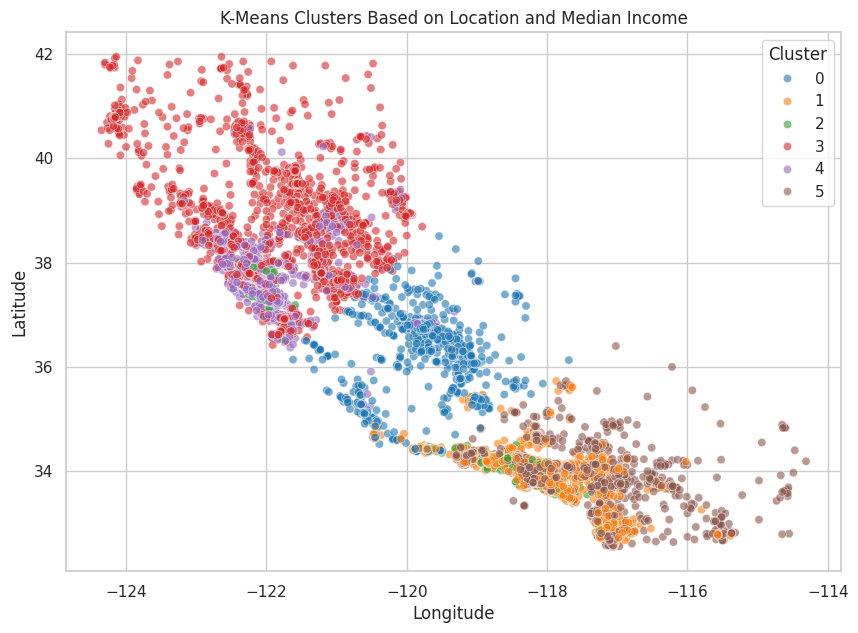

In [14]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train_results,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("K-Means Clusters Based on Location and Median Income")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.show()

/tmp/ipykernel_17319/331872240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


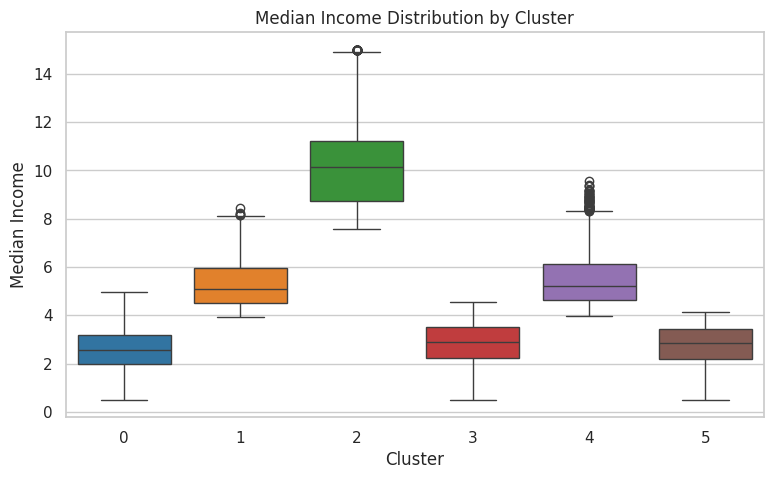

In [15]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=train_results,
    x="cluster",
    y="MedInc",
    palette="tab10"
)

plt.title("Median Income Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Median Income")
plt.show()

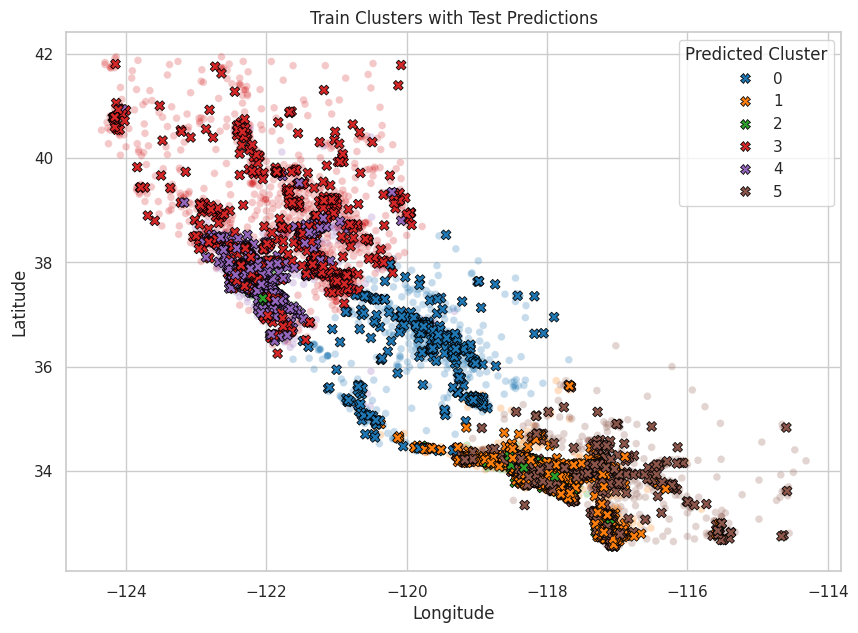

In [16]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train_results,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    alpha=0.25,
    s=30,
    legend=False
)

sns.scatterplot(
    data=test_results,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    marker="X",
    s=50,
    edgecolor="black"
)

plt.title("Train Clusters with Test Predictions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Predicted Cluster")
plt.show()

In [17]:
X_train_sup = X_train.copy()
X_test_sup = X_test.copy()

y_train_sup = train_results["cluster"]
y_test_sup = test_results["cluster"]

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None
)

rf_model.fit(X_train_sup, y_train_sup)

RandomForestClassifier(random_state=42)

In [19]:
y_pred_sup = rf_model.predict(X_test_sup)

y_pred_sup[:10]

array([0, 0, 3, 1, 3, 1, 1, 5, 4, 2], dtype=int32)

In [20]:
accuracy = accuracy_score(y_test_sup, y_pred_sup)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test_sup, y_pred_sup))

Accuracy: 0.9956395348837209

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       1.00      0.99      1.00       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       1.00      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



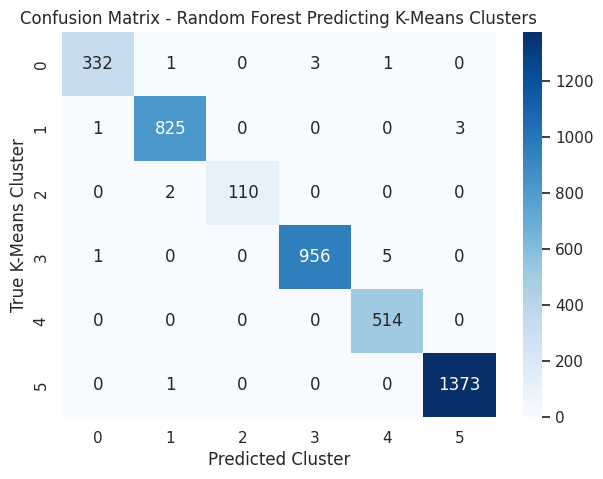

In [21]:
cm = confusion_matrix(y_test_sup, y_pred_sup)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest Predicting K-Means Clusters")
plt.xlabel("Predicted Cluster")
plt.ylabel("True K-Means Cluster")
plt.show()

In [22]:
feature_importance = pd.DataFrame({
    "feature": X_train_sup.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
0,MedInc,0.457697
1,Latitude,0.281308
2,Longitude,0.260996


/tmp/ipykernel_17319/3994875259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


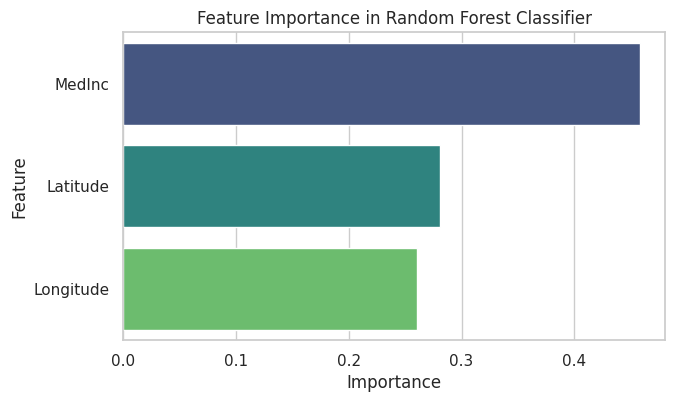

In [23]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Feature Importance in Random Forest Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [24]:
import os

os.makedirs("models", exist_ok=True)

In [25]:
with open("models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

with open("models/kmeans_6_clusters.pkl", "wb") as file:
    pickle.dump(kmeans, file)

with open("models/random_forest_cluster_classifier.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [26]:
with open("models/kmeans_6_clusters.pkl", "rb") as file:
    loaded_kmeans = pickle.load(file)

with open("models/random_forest_cluster_classifier.pkl", "rb") as file:
    loaded_rf = pickle.load(file)

print("Models loaded successfully")

Models loaded successfully


In [ ]:
# En este proyecto se utilizó K-Means para agrupar zonas de California usando ingreso medio, latitud y longitud. Antes de entrenar el modelo, las variables fueron escaladas porque K-Means depende de distancias y puede verse afectado por diferencias de escala.

# El modelo asignó cada zona a uno de seis clusters. Los resultados muestran una estructura principalmente geográfica, aunque el ingreso medio también aporta información socioeconómica.

# Después, los clusters generados por K-Means se usaron como etiquetas para entrenar un modelo supervisado Random Forest. Este segundo modelo aprendió a reproducir las categorías creadas por K-Means.

# Esto representa un flujo común en datos no etiquetados: primero se crean etiquetas con aprendizaje no supervisado y luego se entrena un modelo supervisado para reproducir esas etiquetas. Diferencias claras contra la solución original